# Main Figures 2–6

Initialization, life cycles, RWB, and EKE. Each section contains the plotting code, runs it directly by default, and displays the generated file.


In [1]:
from __future__ import annotations
import hashlib, importlib.metadata, io, json, math, os, re, shutil, sys, zipfile
from contextlib import redirect_stderr, redirect_stdout
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/james-mpl-cache")
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image as NotebookImage, SVG, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import ndimage
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d

try:
    import cartopy.crs as ccrs
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False
try:
    import wavebreaking as wb
    HAVE_WAVEBREAKING = True
except ImportError:
    HAVE_WAVEBREAKING = False
try:
    from contrack import contrack as ConTrack
    HAVE_CONTRACK = True
except ImportError:
    HAVE_CONTRACK = False

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "ready_version").is_dir() and (candidate / "derived_data").is_dir():
            return candidate
    raise FileNotFoundError("Run from the repository or one of its subdirectories")

ROOT = find_repo_root()
RAW_DIR = ROOT
DERIVED_DIR = ROOT / "derived_data"
PUBLICATION_DIR = ROOT / "publication_notebooks"
FIGURE_DIR = PUBLICATION_DIR / "outputs"
TABLE_DIR = PUBLICATION_DIR / "outputs"
SI_DIR = ROOT / "paper_revision" / "supplemental_analysis"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RUN_HEAVY_PROCESSING = False
USE_PRECOMPUTED_DERIVED_DATA = True
SAVE_FIGURES = True
SHOW_FIGURES = False
REBUILD_FIGURES = os.environ.get(
    "PUBLICATION_REBUILD_FIGURES",
    os.environ.get("PUBLICATION_FULL_REBUILD", "1"),
) == "1"
FULL_REBUILD = REBUILD_FIGURES
EARTH_RADIUS_M = 6_371_229.0
EARTH_OMEGA = 7.2921e-5
GRAVITY = 9.80616
RD = 287.05
CP = 1004.0
KAPPA = RD / CP
mpl.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9})

def show_docx_media(docx_relative_path, members):
    members = [members] if isinstance(members, str) else list(members)
    with zipfile.ZipFile(ROOT / docx_relative_path) as archive:
        for member in members:
            payload = archive.read(member)
            display(SVG(data=payload.decode("utf-8")) if member.lower().endswith(".svg") else NotebookImage(data=payload))

def show_files(paths):
    paths = [paths] if isinstance(paths, str) else list(paths)
    for relative_path in paths:
        path = ROOT / relative_path
        if path.exists() and path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
            display(NotebookImage(filename=str(path)))

# Optional environment diagnostics are intentionally disabled in the public notebooks.
# print(f"Repository root: {ROOT.relative_to(ROOT)}")
# print(f"Rebuild figures: {REBUILD_FIGURES}")
# print(f"Cartopy={HAVE_CARTOPY}, WaveBreaking={HAVE_WAVEBREAKING}, ConTrack={HAVE_CONTRACK}")


In [2]:
B_VALUES=(1.0,1.5,2.0); N_VALUES=(1,3,6); S_VALUES=(-10,-5,0,5,10)
def case_stem(b,n,s):
    bt='15' if np.isclose(b,1.5) else str(int(b))
    return f'BCwave_b{bt}n{n}' + ('' if s==0 else f's{s}')
def experiment_manifest():
    rows=[]
    for b in B_VALUES:
      for n in N_VALUES:
       for s in S_VALUES:
        stem=case_stem(b,n,s)
        rows.append({'case':stem.replace('BCwave_',''),'b':b,'n':n,'s_deg':s,
          'raw_file':f'{stem}.nc',
          'coarse_file':f'derived_data/coarse5avg/{stem}.nc',
          'pv_file':f'derived_data/pv_isentropic/{stem}.nc'})
    return pd.DataFrame(rows)
TABLE1=experiment_manifest(); assert len(TABLE1)==45
TABLE1.to_csv(TABLE_DIR/'Table1_experiment_manifest.csv',index=False)
# Optional manifest preview is disabled to keep notebook output figure-only.
# display(TABLE1)


In [3]:
def open_case(case, coarse=False, chunks=None):
    stem=case if str(case).startswith('BCwave_') else f'BCwave_{case}'
    path=(DERIVED_DIR/'coarse5avg' if coarse else RAW_DIR)/f'{stem}.nc'
    if not path.exists(): raise FileNotFoundError(path)
    return xr.open_dataset(path,decode_times=False,chunks=chunks)
def standardize_latlon(obj):
    rename={}
    if 'grid_yt' in obj.dims or 'grid_yt' in obj.coords: rename['grid_yt']='latitude'
    if 'grid_xt' in obj.dims or 'grid_xt' in obj.coords: rename['grid_xt']='longitude'
    return obj.rename(rename)
def daily_mean(ds): return ds.coarsen(time=24,boundary='trim').mean()
def save_figure(fig,name):
    path=FIGURE_DIR/name
    if SAVE_FIGURES: fig.savefig(path,bbox_inches='tight',facecolor='white')
    if SHOW_FIGURES: plt.show()
    else: plt.close(fig)
    return path
def nearest_level(levels,target): return int(np.nanargmin(np.abs(np.asarray(levels)-target)))
def grid_cell_area(latitude,dlat_deg=1.,dlon_deg=1.):
    lat=np.deg2rad(np.asarray(latitude)); dlat=np.deg2rad(dlat_deg); dlon=np.deg2rad(dlon_deg)
    return EARTH_RADIUS_M**2*dlon*(np.sin(lat+dlat/2)-np.sin(lat-dlat/2))
def haversine_m(lat1,lon1,lat2,lon2):
    lat1,lon1,lat2,lon2=map(np.deg2rad,(lat1,lon1,lat2,lon2)); dlat=lat2-lat1; dlon=(lon2-lon1+np.pi)%(2*np.pi)-np.pi
    h=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*EARTH_RADIUS_M*np.arcsin(np.minimum(1,np.sqrt(h)))
def relative_vorticity(u,v,latitude,longitude):
    lat=np.deg2rad(np.asarray(latitude,float)); lon=np.deg2rad(np.asarray(longitude,float)); coslat=np.cos(lat)
    dvdl=np.gradient(np.asarray(v,float),lon,axis=-1,edge_order=2)
    ducos=np.gradient(np.asarray(u,float)*coslat[...,None],lat,axis=-2,edge_order=2)
    with np.errstate(divide='ignore',invalid='ignore'): return (dvdl-ducos)/(EARTH_RADIUS_M*coslat[...,None])
def theta(T,p_hpa): return np.asarray(T)*(1000/np.asarray(p_hpa))**KAPPA
def pressure_pv(u,v,T,p_hpa,latitude,longitude):
    p=np.asarray(p_hpa,float)*100; zeta=relative_vorticity(u,v,latitude,longitude)
    coriolis=(2*EARTH_OMEGA*np.sin(np.deg2rad(latitude)))[None,:,None]
    dtheta_dp=np.gradient(theta(T,np.asarray(p_hpa)[:,None,None]),p,axis=0,edge_order=2)
    return -GRAVITY*(zeta+coriolis)*dtheta_dp*1e6
def area_weights(latitude):
    w=np.cos(np.deg2rad(latitude)); return w/w.sum()


## Figure 2


In [4]:
# Consolidated from paper_revision/figure_updates/rebuild_figure2.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'paper_revision/figure_updates/rebuild_figure2.py')

"""Rebuild Figure 2 from BCwave_b2n3/ic_validation.ipynb cell 2."""
import sys
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm
ROOT = Path(__file__).resolve().parents[2]
BASE_STATE_DIR = ROOT.parent / 'BCwave_b2n3'
OUTDIR = ROOT / 'current_version' / 'updated_figures'
sys.path.insert(0, str(BASE_STATE_DIR))
from base_state import basic_state_generator_gfdl_shift
vertical_coords = np.array([0.001, 0.00395, 0.00808, 0.01361, 0.02064, 0.02944, 0.04067, 0.05505, 0.07328, 0.09602, 0.12387, 0.15743, 0.19729, 0.24395, 0.29786, 0.35909, 0.4266, 0.49748, 0.56756, 0.63328, 0.6928, 0.7456, 0.79178, 0.83167, 0.86578, 0.89472, 0.91911, 0.93955, 0.95662, 0.97079, 0.98256, 0.99223], dtype=np.float32) * 1000

def generate_variables(base_state_gen):
    return {'ua': base_state_gen.generate_zonal_u(IsPerturbation=False), 'Tv': base_state_gen.generate_T_v()}

def convert_to_dataarray(data, var_name):
    values = np.mean(data, axis=-1).squeeze(axis=0)
    levels = np.arange(1, 33)
    latitudes = np.linspace(-89.95, 89.95, values.shape[1])
    return xr.DataArray(values, coords={'level': levels, 'lat': latitudes}, dims=['level', 'lat'], name=var_name)

def plot_figure2_original() -> Path:
    levels_tv = np.linspace(-60, 30, 19)
    cmap_tv = 'RdBu_r'
    norm_tv = BoundaryNorm(levels_tv, ncolors=plt.get_cmap(cmap_tv).N, clip=True)
    levels_contour = np.arange(-60, 30.1, 10)
    levels_ua = np.arange(5, 41, 5)
    cmap_ua = plt.get_cmap('Reds')
    norm_ua = BoundaryNorm(levels_ua, ncolors=cmap_ua.N, clip=True)
    shifts = [0, 10, 20]
    perturbation_center_base_deg = 40.0
    perturbation_sigma_deg = np.rad2deg(0.1 / np.sqrt(2.0))
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 24), dpi=200, sharex='col', sharey=True)
    letters_left = ['(a) Zonal wind ($u$), $s=0^\\circ$', '(b) Zonal wind ($u$), $s=10^\\circ$', '(c) Zonal wind ($u$), $s=20^\\circ$']
    letters_right = ['(d) Virtual temperature ($T_v$), $s=0^\\circ$', '(e) Virtual temperature ($T_v$), $s=10^\\circ$', '(f) Virtual temperature ($T_v$), $s=20^\\circ$']
    image_ua = None
    image_tv = None
    for index, shift in enumerate(shifts):
        base_state = basic_state_generator_gfdl_shift(b=2, n=3, phi_shift=shift)
        variables = generate_variables(base_state)
        ua = convert_to_dataarray(variables['ua'], 'ua')
        tv = convert_to_dataarray(variables['Tv'], 'Tv') - 273.15
        axis_ua = axes[index, 0]
        image_ua = axis_ua.pcolormesh(ua.lat, vertical_coords, ua, cmap=cmap_ua, norm=norm_ua, shading='nearest')
        perturbation_center_deg = perturbation_center_base_deg + shift
        axis_ua.axvspan(perturbation_center_deg - 2.0 * perturbation_sigma_deg, perturbation_center_deg + 2.0 * perturbation_sigma_deg, color='0.5', alpha=0.3, linewidth=0, zorder=2)
        contours_ua = axis_ua.contour(ua.lat, vertical_coords, ua, levels=levels_ua, colors='k', linewidths=1.0, linestyles='solid', zorder=3)
        axis_ua.clabel(contours_ua, fmt='%1.0f', inline=True, fontsize=15)
        axis_ua.set_ylabel('Pressure (hPa)', fontsize=21)
        axis_ua.invert_yaxis()
        axis_ua.set_yticks([1000, 700, 400, 100])
        axis_ua.tick_params(axis='both', labelsize=18)
        axis_ua.set_title(letters_left[index], fontsize=23, fontweight='bold', pad=10)
        if index == 2:
            axis_ua.set_xlabel('Latitude (°N)', fontsize=21)
        axis_tv = axes[index, 1]
        image_tv = axis_tv.pcolormesh(tv.lat, vertical_coords, tv, cmap=cmap_tv, norm=norm_tv, shading='nearest')
        contours_tv = axis_tv.contour(tv.lat, vertical_coords, tv, levels=levels_contour, colors='k', linewidths=0.8)
        axis_tv.clabel(contours_tv, fmt='%1.0f', inline=True, fontsize=15)
        axis_tv.tick_params(axis='both', labelsize=18)
        axis_tv.set_title(letters_right[index], fontsize=23, fontweight='bold', pad=10)
        if index == 2:
            axis_tv.set_xlabel('Latitude (°N)', fontsize=21)
        axis_tv.set_yticks([1000, 700, 400, 100])
    fig.subplots_adjust(left=0.07, right=0.93, top=0.95, bottom=0.07, hspace=0.25, wspace=0.15)
    common_pad = 0.1
    colorbar_ua = fig.colorbar(image_ua, ax=axes[:, 0].tolist(), orientation='horizontal', pad=common_pad, fraction=0.04, ticks=levels_ua, extend='max')
    colorbar_ua.set_label('Zonal Wind $u$ (m/s)', fontsize=21)
    colorbar_ua.ax.tick_params(labelsize=16)
    colorbar_tv = fig.colorbar(image_tv, ax=axes[:, 1].tolist(), orientation='horizontal', pad=common_pad, fraction=0.04, ticks=levels_tv, extend='both')
    colorbar_tv.set_label('Virtual Temperature (°C)', fontsize=21)
    colorbar_tv.ax.tick_params(labelsize=16)
    OUTDIR.mkdir(parents=True, exist_ok=True)
    output = OUTDIR / 'Figure2_corrected.png'
    shaded_output = OUTDIR / 'Figure2_panel_titles_and_shading_corrected.png'
    pdf_output = OUTDIR / 'Figure2_panel_titles_and_shading_corrected.pdf'
    fig.savefig(output, dpi=160, facecolor='white', bbox_inches='tight')
    fig.savefig(shaded_output, dpi=160, facecolor='white', bbox_inches='tight')
    fig.savefig(pdf_output, facecolor='white', bbox_inches='tight')
    plt.close(fig)
    return shaded_output

def plot_figure2():
    source = plot_figure2_original()
    output = FIGURE_DIR / 'Figure2_initial_jet_and_temperature.png'
    shutil.copy2(source, output)
    return output


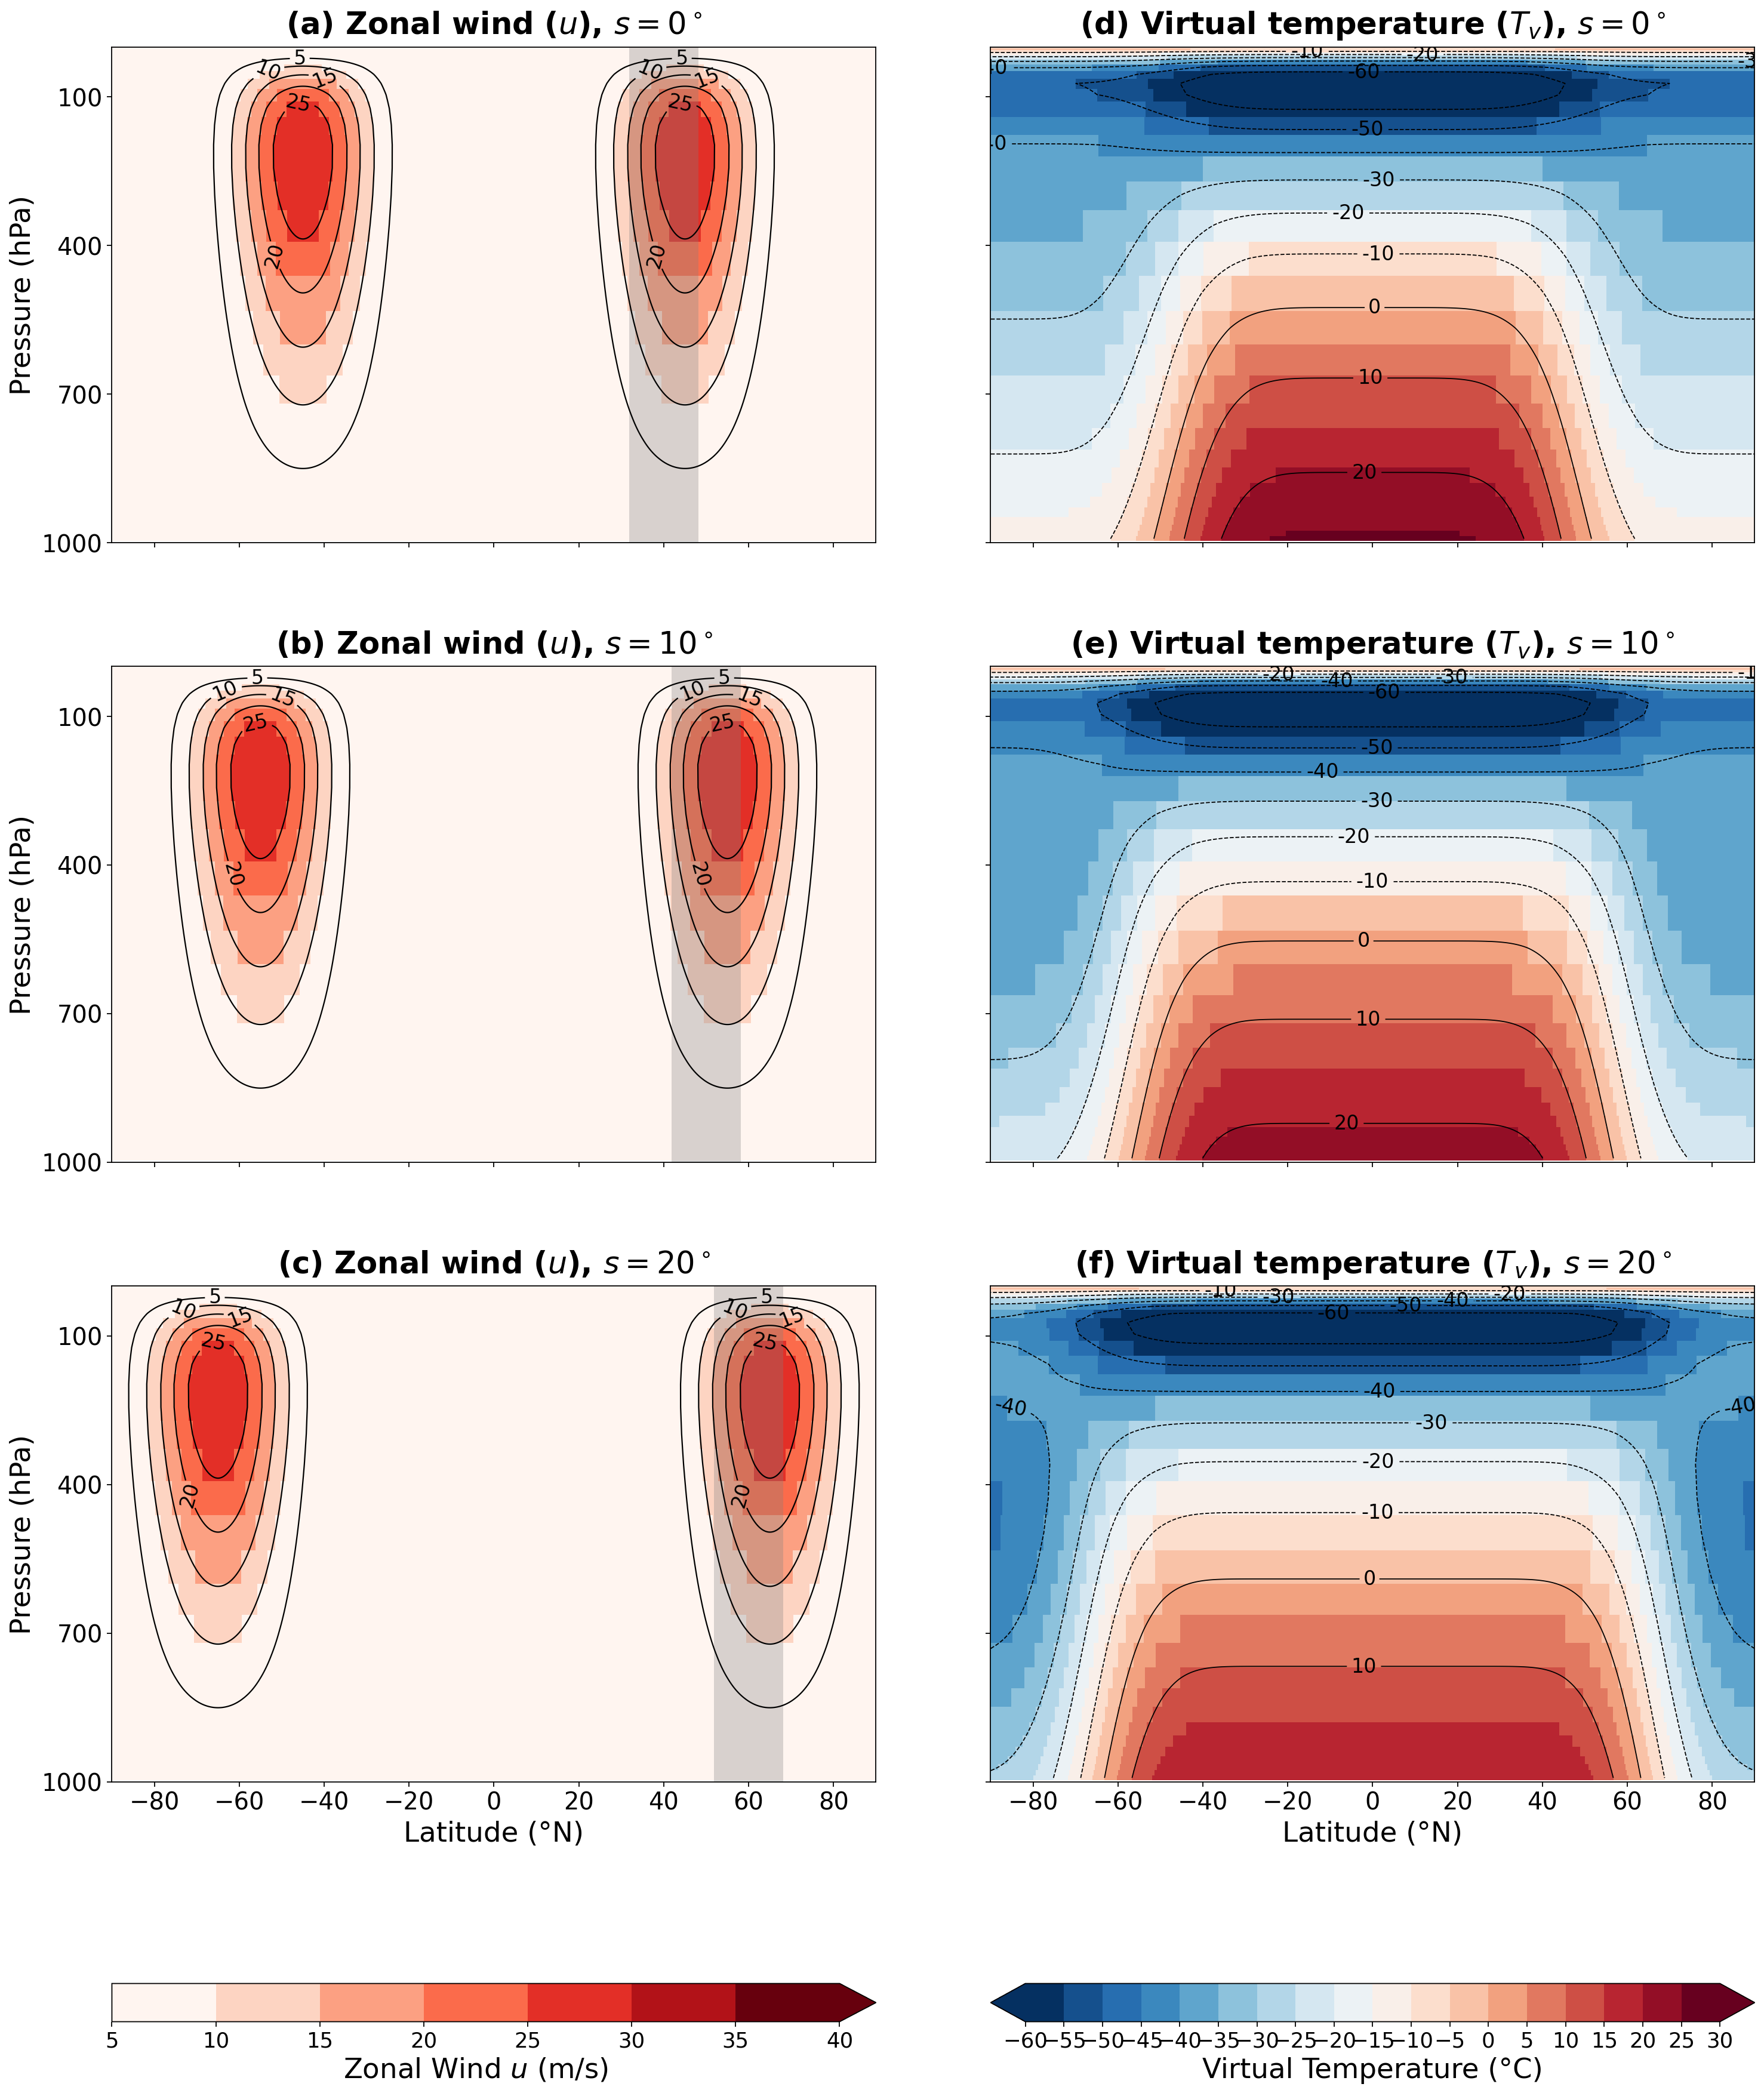

In [5]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure2()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure2_initial_jet_and_temperature.png'])


## Figure 3


In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
levels_pres = np.linspace(70000, 130000, 101)
levels_temp = np.linspace(-30, 30, 31)
cmap_temp = 'RdBu_r'

def _plot_figure3_left(path, file):
    """
    translated note hourly Outputfile（translated note BCwave_b2n3.nc），
    translated notetimetranslated note，translated note 24 hourstranslated note daily-mean，
    translated note Day 6, 8, 10, 12, 14 translated note：
        - surface pressure PRESsfc translated note（low pressuretranslated note，high pressuretranslated note）
        - 850 hPa translated noteshading（K translated note °C）
    """
    ds_hourly = xr.open_dataset(f'{path}/{file}.nc', decode_times=False)
    ds_daily = ds_hourly.coarsen(time=24, boundary='trim').mean()
    fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), dpi=300, sharex=True, sharey=True)
    days = [6, 8, 10, 12, 14]
    threshold = 100000
    for i, day in enumerate(days):
        ax_target = ax[i]
        pres = ds_daily['PRESsfc'].isel(time=day, grid_yt=slice(30 + 90, 80 + 90), grid_xt=slice(50, 250))
        levels_low = levels_pres[levels_pres < threshold]
        levels_high = levels_pres[levels_pres > threshold]
        pres.plot.contour(ax=ax_target, levels=levels_low, colors='k', linewidths=1, linestyles='solid', add_colorbar=False)
        pres.plot.contour(ax=ax_target, levels=levels_high, colors='k', linewidths=1, linestyles='dashed', add_colorbar=False)
        temp850 = ds_daily['t_plev'].sel(plev=850).isel(time=day, grid_yt=slice(30 + 90, 80 + 90), grid_xt=slice(50, 250))
        temp850_C = temp850 - 273.15
        cs = temp850_C.plot.contourf(ax=ax_target, levels=levels_temp, cmap=cmap_temp, extend='both', add_colorbar=False)
        ax_target.set_ylim(30, 80)
        ax_target.set_yticks([30, 55, 80])
        ax_target.set_yticklabels(['30°N', '55°N', '80°N'], fontsize=15)
        ax_target.axhline(40, linestyle='dashed', linewidth=2, color='k')
        ax_target.set_xticks([60, 120, 180, 240])
        ax_target.set_xticklabels(['60°E', '120°E', '180°', '120°W'], fontsize=15)
        ax_target.tick_params(axis='x', labelsize=10)
        if i == 2:
            ax_target.set_xlabel(' ', fontsize=20)
        else:
            ax_target.set_xlabel('')
        ax_target.set_ylabel('')
        ax_target.set_title('')
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    fig.subplots_adjust(hspace=0.2)
    cbar_ax = fig.add_axes([0.15, 0.03, 0.7, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar.set_label('Temperature (°C)', fontsize=20)
    cbar.set_ticks(np.arange(-30, 31, 6))
    cbar.ax.tick_params(labelsize=20)
    return fig

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
levels_pres = np.linspace(70000, 130000, 101)
levels_temp = np.linspace(-30, 30, 31)
cmap_temp = 'RdBu_r'

def _plot_figure3_right(path, file):
    """
    translated note hourly Outputfile（translated note BCwave_b2n3.nc），
    translated notetimetranslated note，translated note 24 hourstranslated note daily-mean，
    translated note Day 6, 8, 10, 12, 14 translated note：
        - surface pressure PRESsfc translated note（low pressuretranslated note，high pressuretranslated note）
        - 850 hPa translated noteshading（K translated note °C）
    """
    ds_hourly = xr.open_dataset(f'{path}/{file}.nc', decode_times=False)
    ds_daily = ds_hourly.coarsen(time=24, boundary='trim').mean()
    fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), dpi=300, sharex=True, sharey=True)
    days = [6, 8, 10, 12, 14]
    threshold = 100000
    for i, day in enumerate(days):
        ax_target = ax[i]
        pres = ds_daily['PRESsfc'].isel(time=day, grid_yt=slice(30 + 90, 80 + 90), grid_xt=slice(50, 250))
        levels_low = levels_pres[levels_pres < threshold]
        levels_high = levels_pres[levels_pres > threshold]
        pres.plot.contour(ax=ax_target, levels=levels_low, colors='k', linewidths=1, linestyles='solid', add_colorbar=False)
        pres.plot.contour(ax=ax_target, levels=levels_high, colors='k', linewidths=1, linestyles='dashed', add_colorbar=False)
        temp850 = ds_daily['t_plev'].sel(plev=850).isel(time=day, grid_yt=slice(30 + 90, 80 + 90), grid_xt=slice(50, 250))
        temp850_C = temp850 - 273.15
        cs = temp850_C.plot.contourf(ax=ax_target, levels=levels_temp, cmap=cmap_temp, extend='both', add_colorbar=False)
        ax_target.set_ylim(30, 80)
        ax_target.set_yticks([30, 55, 80])
        ax_target.set_yticklabels(['30°N', '55°N', '80°N'], fontsize=15)
        ax_target.axhline(50, linestyle='dashed', linewidth=2, color='k')
        ax_target.set_xticks([60, 120, 180, 240])
        ax_target.set_xticklabels(['60°E', '120°E', '180°', '120°W'], fontsize=15)
        ax_target.tick_params(axis='x', labelsize=10)
        if i == 2:
            ax_target.set_xlabel(' ', fontsize=20)
        else:
            ax_target.set_xlabel('')
        ax_target.set_ylabel('')
        ax_target.set_title('')
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    fig.subplots_adjust(hspace=0.2)
    cbar_ax = fig.add_axes([0.15, 0.03, 0.7, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar.set_label('Temperature (°C)', fontsize=20)
    cbar.set_ticks(np.arange(-30, 31, 6))
    cbar.ax.tick_params(labelsize=20)
    return fig
def plot_figure3():
    from PIL import Image as PILImage
    figures = [_plot_figure3_left(str(RAW_DIR), 'BCwave_b2n3'), _plot_figure3_right(str(RAW_DIR), 'BCwave_b2n3s10')]
    images = []
    for figure in figures:
        buffer = io.BytesIO()
        figure.savefig(buffer, format='png', dpi=150, bbox_inches='tight', facecolor='white')
        buffer.seek(0)
        images.append(PILImage.open(buffer).convert('RGB').copy())
        plt.close(figure)
    height = max(image.height for image in images)
    resized = [image.resize((round(image.width * height / image.height), height), PILImage.Resampling.LANCZOS) for image in images]
    canvas = PILImage.new('RGB', (sum(image.width for image in resized), height), 'white')
    offset = 0
    for image in resized:
        canvas.paste(image, (offset, 0)); offset += image.width
    output = FIGURE_DIR / 'Figure3_surface_pressure_temperature_lifecycle.png'
    canvas.save(output, dpi=(300, 300))
    return output


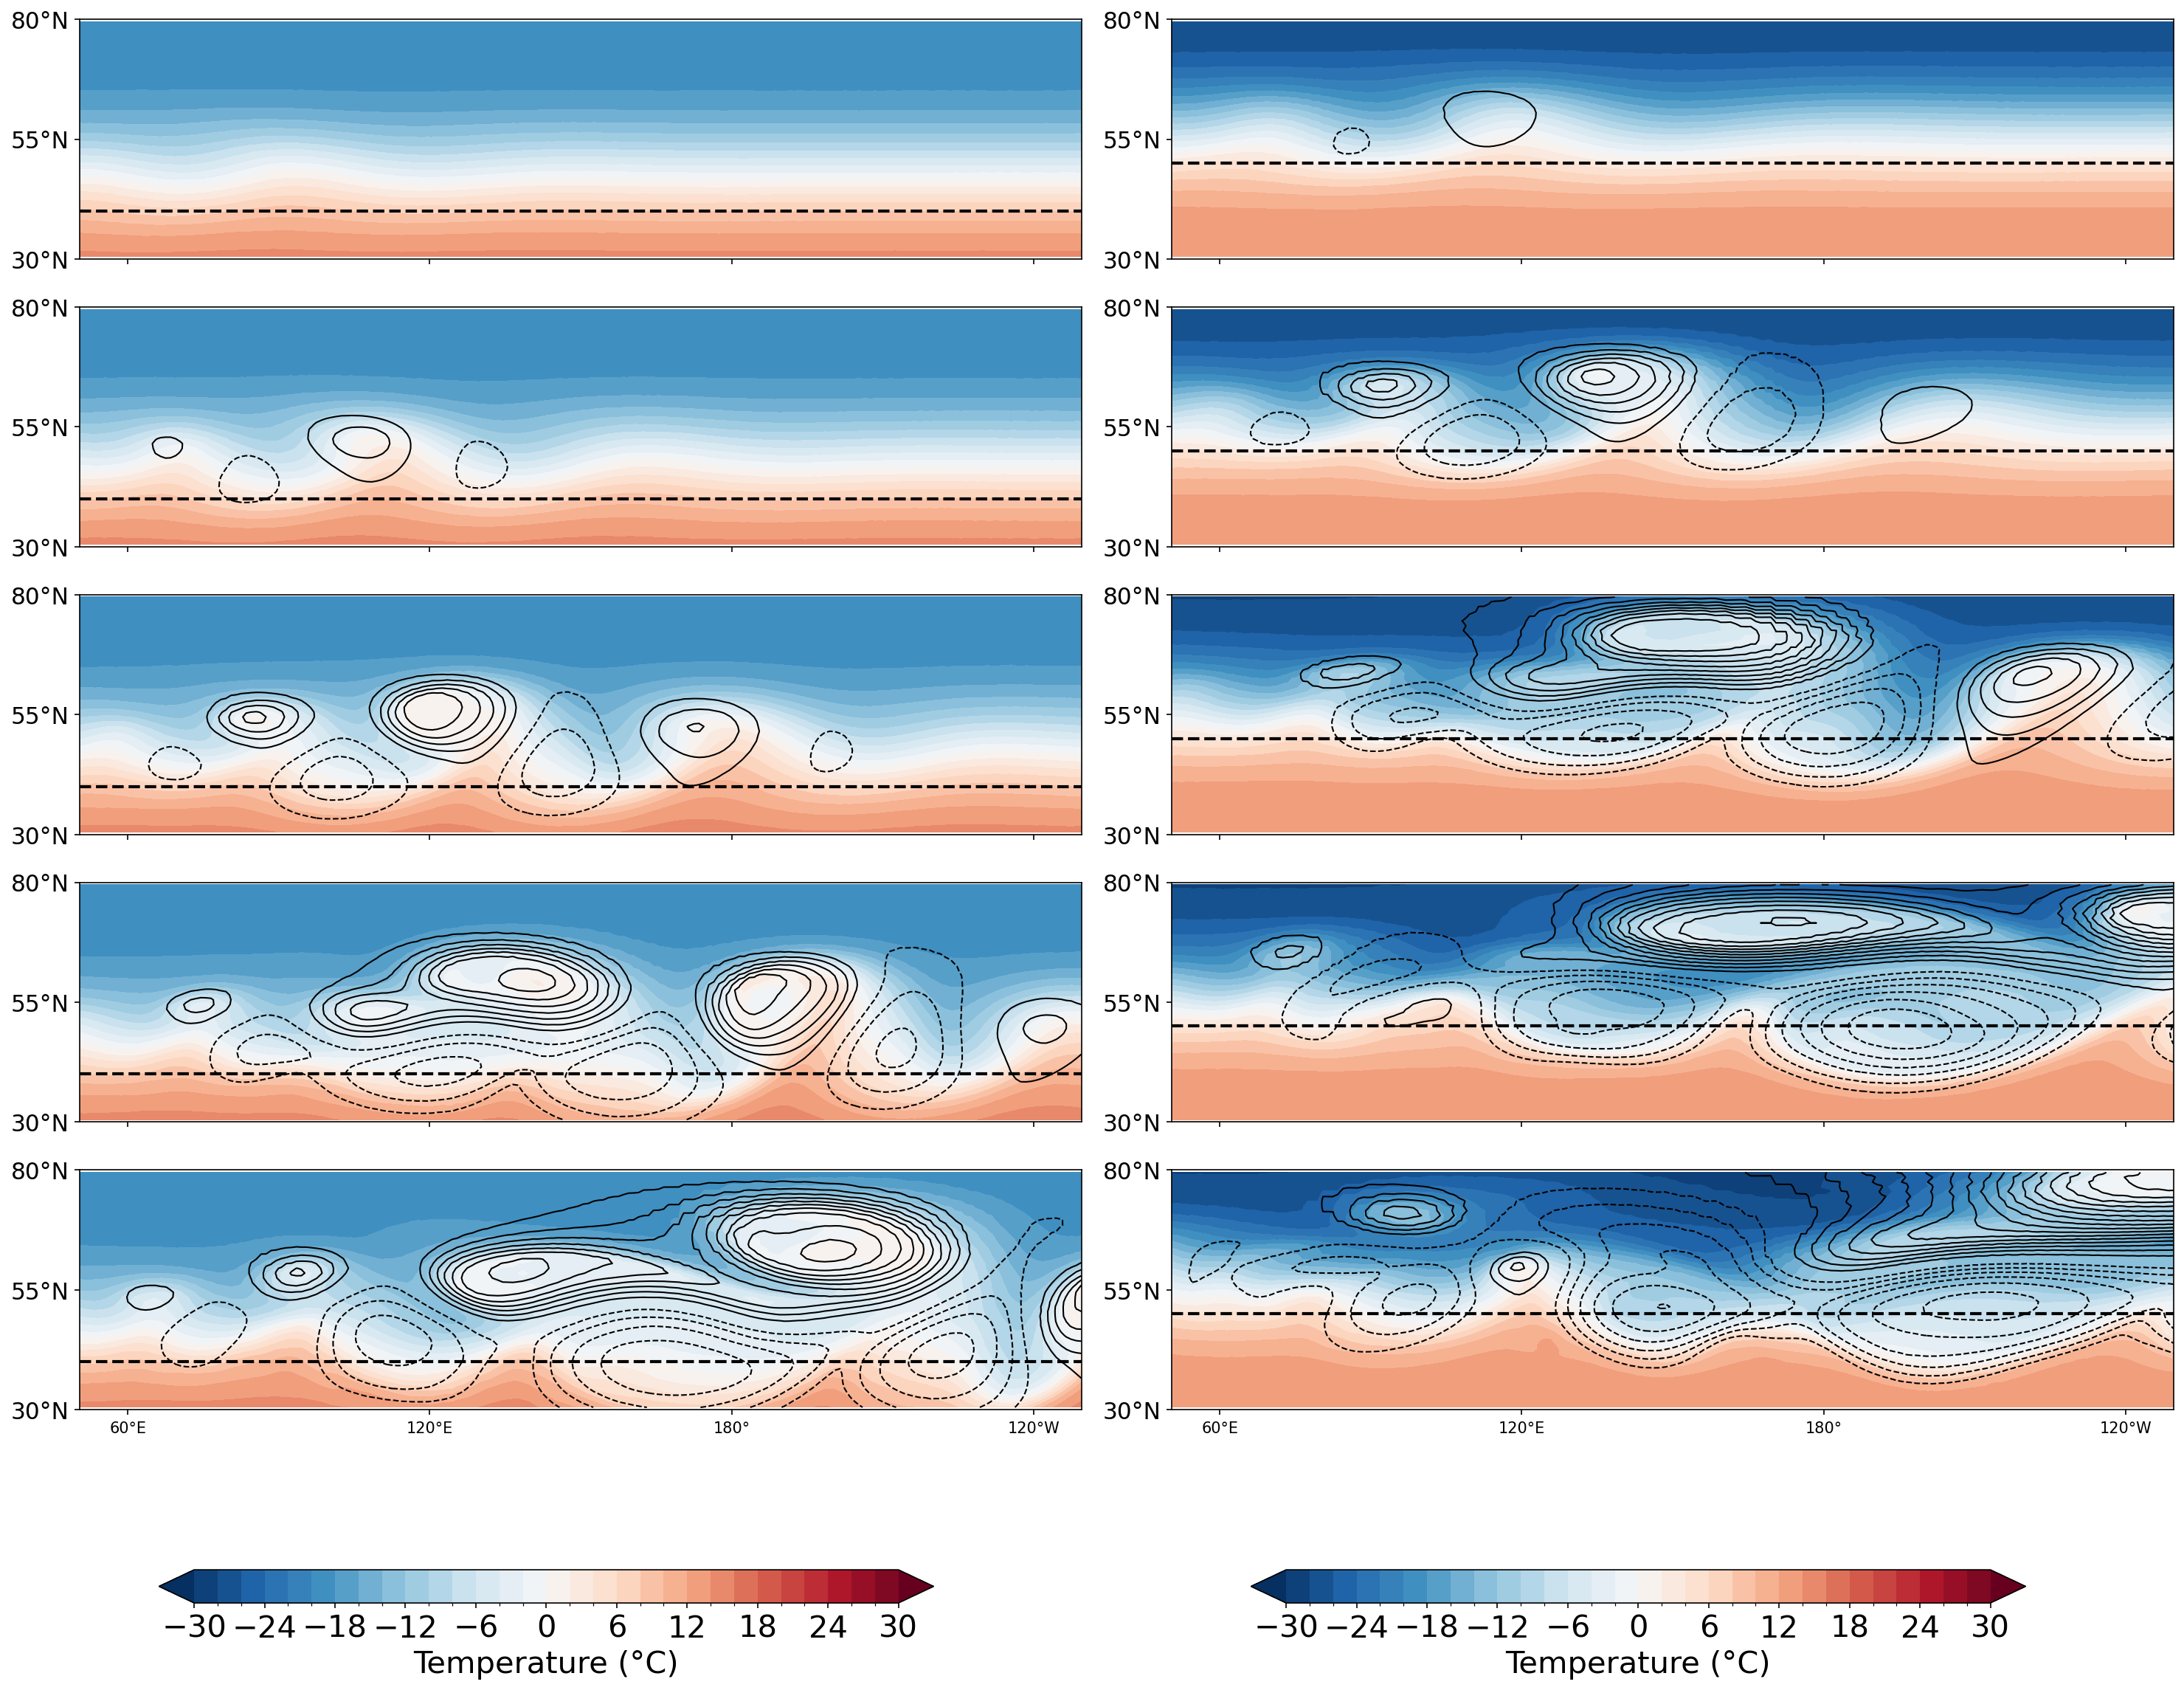

In [7]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure3()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure3_surface_pressure_temperature_lifecycle.png'])


## Figure 4


In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter
levels_h = np.arange(8000, 11000, 100)
levels_vort = np.linspace(-0.00012, 0.00012, 13)
n_segments = len(levels_vort) - 1
base_cmap = plt.get_cmap('BrBG', n_segments)
colors = base_cmap(np.linspace(0, 1, n_segments))
colors[5] = [1, 1, 1, 1]
colors[6] = [1, 1, 1, 1]
custom_cmap = ListedColormap(colors)
norm_vort = BoundaryNorm(levels_vort, n_segments, clip=True)
EARTH_RADIUS = 6371000.0

def compute_vort500(ds_inst):
    """
    fromtranslated notecentertranslated note u_plev / v_plev and grid_yt_bnds / grid_xt_bnds
    compute 500 hPa translated notevorticitytranslated note，return DataArray: (time, grid_yt, grid_xt)，units s^-1
    """
    lat_bnds = ds_inst['grid_yt_bnds']
    lon_bnds = ds_inst['grid_xt_bnds']
    lat = lat_bnds.mean('bnds')
    lon = lon_bnds.mean('bnds')
    u500 = ds_inst['u_plev'].sel(plev=500)
    v500 = ds_inst['v_plev'].sel(plev=500)
    u500 = u500.assign_coords(grid_yt=lat, grid_xt=lon)
    v500 = v500.assign_coords(grid_yt=lat, grid_xt=lon)
    phi = np.deg2rad(lat)
    cosphi = np.cos(phi)
    ucos = u500 * cosphi
    factor_deg2rad = 180.0 / np.pi
    d_v_dlon = v500.differentiate('grid_xt') * factor_deg2rad
    d_ucos_dlat = ucos.differentiate('grid_yt') * factor_deg2rad
    vort = (d_v_dlon - d_ucos_dlat) / (EARTH_RADIUS * cosphi)
    vort = vort.rename('VORT500')
    vort.attrs['long_name'] = '500 hPa relative vorticity'
    vort.attrs['units'] = 's^-1'
    return vort

def _plot_figure4_original(path, file):
    ds_hourly = xr.open_dataset(f'{path}/{file}.nc', decode_times=False)
    ds_inst = ds_hourly.isel(time=slice(0, None, 24))
    vort500_all = compute_vort500(ds_inst)
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), dpi=300, sharex=True, sharey=True)
    days = [6, 8, 10, 12, 14]
    for i, day in enumerate(days):
        ax = axes[i]
        h300 = ds_inst['h_plev'].sel(plev=300).isel(time=day, grid_yt=slice(30 + 90, 80 + 90), grid_xt=slice(50, 250))
        h300.plot.contour(ax=ax, levels=levels_h, colors='k', linewidths=1, linestyles='solid', add_colorbar=False)
        vort500 = vort500_all.isel(time=day, grid_yt=slice(30 + 90, 80 + 90), grid_xt=slice(50, 250))
        cf = ax.contourf(vort500['grid_xt'], vort500['grid_yt'], vort500, levels=levels_vort, cmap=custom_cmap, norm=norm_vort, extend='both')
        ax.set_ylim(30, 80)
        ax.set_yticks([30, 55, 80])
        ax.set_yticklabels(['30°N', '55°N', '80°N'], fontsize=15)
        ax.axhline(50, linestyle='dashed', linewidth=2.5, color='k', zorder=5)
        ax.set_xticks([60, 120, 180, 240])
        ax.set_xticklabels(['60°E', '120°E', '180°', '120°W'], fontsize=15)
        if i == 4:
            ax.set_xlabel('Longitude', fontsize=20)
        else:
            ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'Day {day}', loc='left', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    fig.subplots_adjust(hspace=0.2)
    cax = fig.add_axes([0.15, 0.03, 0.7, 0.02])
    cb = fig.colorbar(cf, cax=cax, orientation='horizontal', extend='both')
    cb.set_label('500 hPa Vorticity (s⁻¹)', fontsize=20)
    cb.set_ticks(levels_vort)

    def fmt(x, pos):
        return f'{x / 0.0001:.1f}'
    cb.ax.xaxis.set_major_formatter(FuncFormatter(fmt))
    cb.ax.text(1.02, 0.5, '$\\times 10^{-4}$', transform=cb.ax.transAxes, va='center', ha='left', fontsize=12)
    cb.ax.tick_params(labelsize=15)
    return fig


def plot_figure4():
    from PIL import Image as PILImage
    images = []
    for filename, title in [
        ('BCwave_b2n3', 'b=2, n=3, s=0'),
        ('BCwave_b2n3s10', 'b=2, n=3, s=10'),
    ]:
        figure = _plot_figure4_original(str(RAW_DIR), filename)
        for axis in figure.axes[:5]:
            axis.set_title('', loc='center')
        figure.suptitle(title, fontsize=20, y=0.995)
        buffer = io.BytesIO()
        figure.savefig(buffer, format='png', dpi=150, bbox_inches='tight', facecolor='white')
        buffer.seek(0)
        images.append(PILImage.open(buffer).convert('RGB').copy())
        plt.close(figure)
    height = max(image.height for image in images)
    resized = [
        image.resize((round(image.width * height / image.height), height), PILImage.Resampling.LANCZOS)
        for image in images
    ]
    panel_height = round(height * 0.86)
    colorbar = resized[-1].crop((
        round(resized[-1].width * 0.10),
        round(height * 0.87),
        round(resized[-1].width * 0.90),
        height,
    ))
    canvas_width = sum(image.width for image in resized)
    canvas = PILImage.new('RGB', (canvas_width, panel_height + colorbar.height), 'white')
    offset = 0
    for image in resized:
        canvas.paste(image.crop((0, 0, image.width, panel_height)), (offset, 0))
        offset += image.width
    canvas.paste(colorbar, ((canvas_width - colorbar.width) // 2, panel_height))
    output = FIGURE_DIR / 'Figure4_upper_level_lifecycle.png'
    canvas.save(output, dpi=(300, 300))
    return output


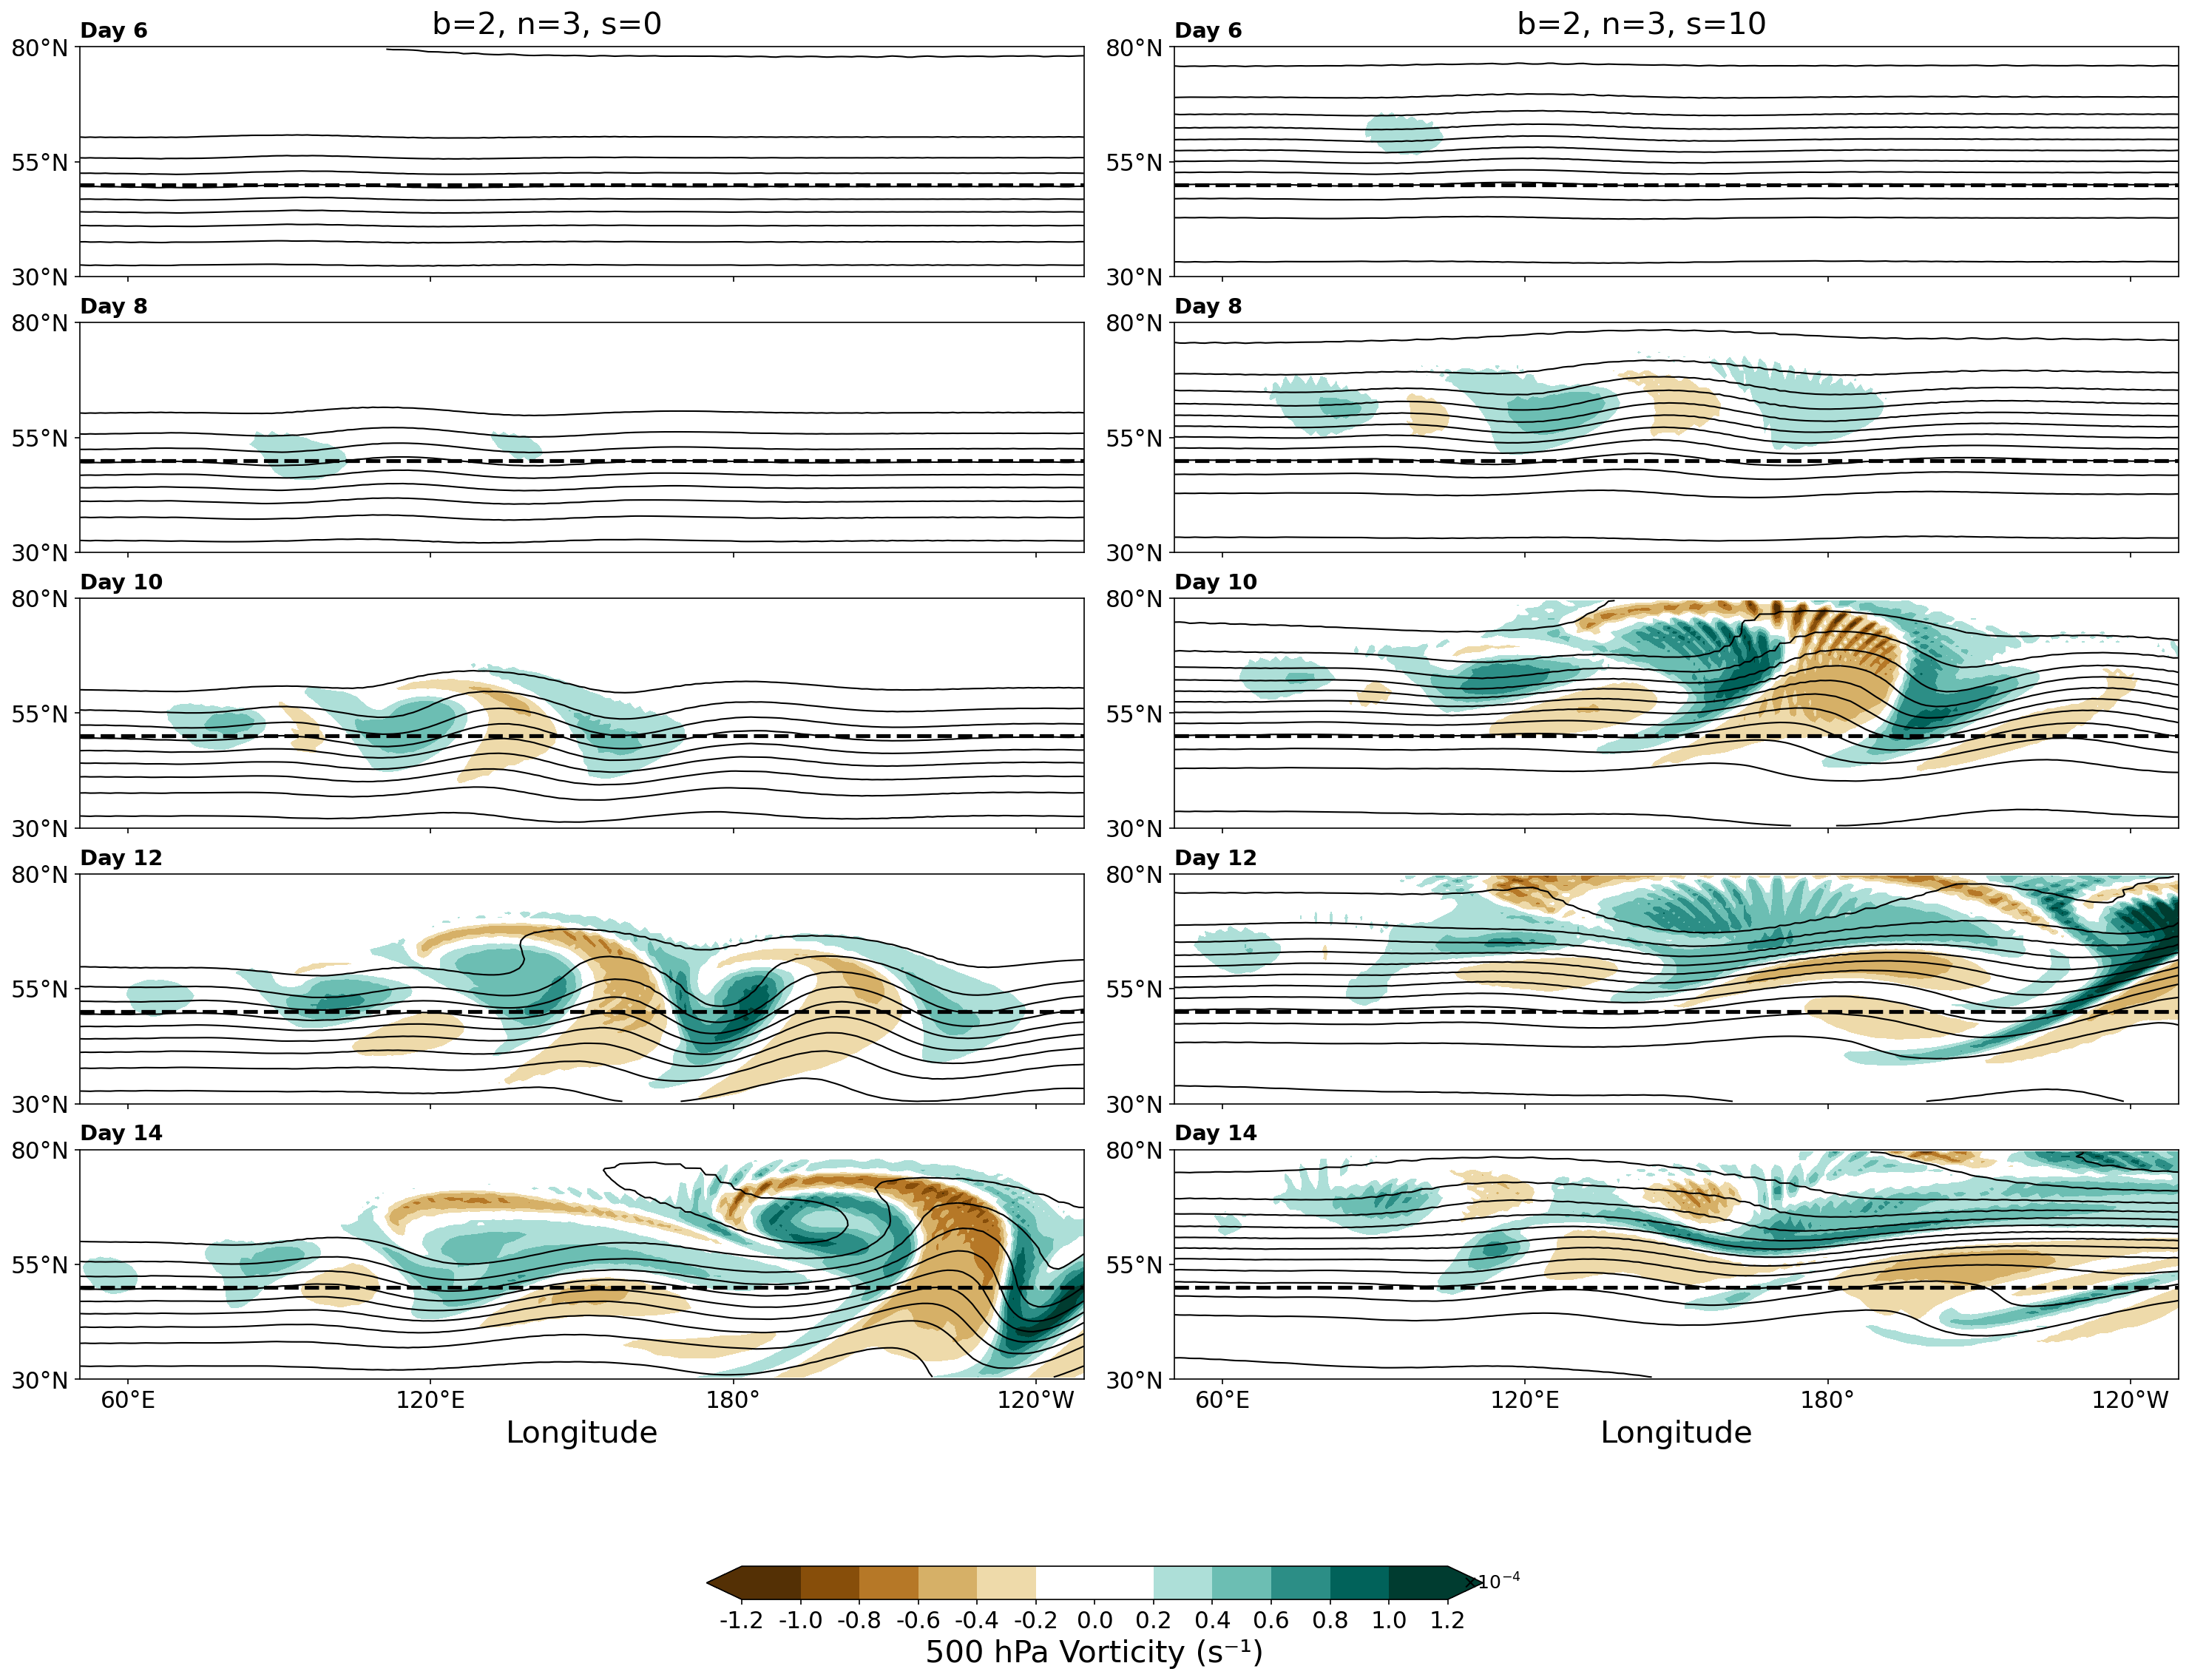

In [9]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure4()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure4_upper_level_lifecycle.png'])


## Figure 5


In [10]:
import os, re, sys, traceback
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wavebreaking as wb
from matplotlib.ticker import PercentFormatter, MultipleLocator
from matplotlib import patheffects as pe
from matplotlib.patches import Patch
data_dir = str(DERIVED_DIR / 'pv_isentropic')
theta = 330.0
pv_level = 2.0
key = f'{int(theta)}K'
pv_name, u_name, v_name = (f'pv_{key}', f'u_{key}', f'v_{key}')
plt.rcParams.update({'figure.figsize': (8, 10), 'axes.titlesize': 21, 'axes.labelsize': 18, 'xtick.labelsize': 16.5, 'ytick.labelsize': 16.5, 'legend.fontsize': 16.5})
COLOR_CYC = '#fc9274'
COLOR_ANT = '#9ecae1'
BAR_HEIGHT = 0.7
BG_COLOR = 'white'

def _cfize_latlon(da):
    ren = {}
    if 'grid_yt' in da.dims:
        ren['grid_yt'] = 'latitude'
    if 'grid_xt' in da.dims:
        ren['grid_xt'] = 'longitude'
    da2 = da.rename(ren)
    if 'latitude' in da2.coords:
        da2['latitude'].attrs['units'] = 'degrees_north'
    if 'longitude' in da2.coords:
        da2['longitude'].attrs['units'] = 'degrees_east'
    return da2

def _ensure_time_dim(da, ds):
    if 'time' in da.dims:
        return da
    if 'time' in ds.coords:
        tcoord = ds['time']
        if tcoord.ndim == 1:
            return da.expand_dims({'time': tcoord}).assign_coords(time=tcoord)
        elif tcoord.ndim == 0:
            return da.expand_dims({'time': [tcoord.item()]})
    return da

def _sort_if_needed(da, dim):
    try:
        if dim in da.dims and (da[dim].diff(dim) < 0).any():
            return da.sortby(dim)
    except Exception:
        pass
    return da

def _collect_records():
    nc_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.nc')]
    if not nc_files:
        raise RuntimeError(f'directorycenterno .nc file：{data_dir}')
    records = []
    for f in sorted(nc_files):
        base = os.path.basename(f)
        m_b = re.search('b(\\d+)', base)
        if m_b:
            b_int = int(m_b.group(1))
            bval = 1.5 if b_int == 15 else float(b_int)
        else:
            bval = None
        m_n = re.search('n(\\d+)', base)
        nval = int(m_n.group(1)) if m_n else None
        m_s = re.search('s(-?\\d+)', base)
        sval = int(m_s.group(1)) if m_s else 0
        try:
            ds = xr.open_dataset(f, decode_times=False)
            if not all((v in ds for v in (pv_name, u_name, v_name))):
                print(f'[skip] {base}: translated note {pv_name}/{u_name}/{v_name}')
                continue
            PV = _ensure_time_dim(ds[pv_name], ds)
            U = _ensure_time_dim(ds[u_name], ds)
            V = _ensure_time_dim(ds[v_name], ds)
            PV = _cfize_latlon(PV).transpose('time', 'latitude', 'longitude')
            U = _cfize_latlon(U).transpose('time', 'latitude', 'longitude')
            V = _cfize_latlon(V).transpose('time', 'latitude', 'longitude')
            PV = _sort_if_needed(PV, 'latitude')
            U = _sort_if_needed(U, 'latitude')
            V = _sort_if_needed(V, 'latitude')
            smoothed = wb.calculate_smoothed_field(PV, passes=5, mode='wrap')
            mflux = wb.calculate_momentum_flux(U, V)
            contours = wb.calculate_contours(data=smoothed, contour_levels=[-pv_level, pv_level], original_coordinates=False)
            ovt = wb.calculate_overturnings(data=smoothed, contour_levels=[-pv_level, pv_level], contours=contours, range_group=5, min_exp=1, intensity=mflux, periodic_add=0)
            try:
                cols = list(ovt.columns)
                if 'geometry' in cols:
                    df = pd.DataFrame(ovt.drop(columns='geometry'))
                else:
                    df = pd.DataFrame(ovt)
            except Exception:
                df = pd.DataFrame(ovt)
            if df is None or df.empty or 'orientation' not in df.columns:
                print(f'[skip] {base}: eventtranslated noteastranslated noteortranslated note orientation。')
                continue
            df['orientation'] = df['orientation'].astype(str).str.lower()
            cyc_count = int(df['orientation'].str.startswith('cyclonic').sum())
            ant_count = int(df['orientation'].str.startswith('anticyclonic').sum())
            records.append({'s': sval, 'b': bval, 'n': nval, 'cyclonic': cyc_count, 'anticyclonic': ant_count})
        except Exception as e:
            print(f'[skip] {base}: {e}')
            traceback.print_exc(file=sys.stdout)
    if not records:
        raise RuntimeError('notranslated noteeventtranslated note，translated noteskipreason。')
    return pd.DataFrame(records)

def _prep_group(df, by_col):
    g = df.groupby(by_col)[['cyclonic', 'anticyclonic']].sum()
    g = g[g.sum(axis=1) > 0].sort_index()
    tot = g.sum(axis=1)
    cyc_frac = (g['cyclonic'] / tot).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    ant_frac = (g['anticyclonic'] / tot).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out = g.copy()
    out['total'] = tot
    out['cyclonic_frac'] = cyc_frac
    out['anticyclonic_frac'] = ant_frac
    return out

def plot_figure5():
    df_all = _collect_records()
    g_s = _prep_group(df_all.dropna(subset=['s']), by_col='s')
    g_b = _prep_group(df_all.dropna(subset=['b']), by_col='b')
    g_n = _prep_group(df_all.dropna(subset=['n']), by_col='n')
    g_n = g_n.sort_index(ascending=False)
    g_b = g_b.sort_index(ascending=True)
    g_s = g_s.sort_index(ascending=True)
    groups = [('n', g_n, '$n$'), ('b', g_b, '$b$'), ('s', g_s, '$s$')]
    ys = []
    labels = []
    cyc_frac_list = []
    ant_frac_list = []
    cyc_count_list = []
    ant_count_list = []
    group_spans = []
    y_pos = 0.0
    row_step = 1.0
    group_gap = 0.7
    for g_name, g_df, g_label in groups:
        if g_df.empty:
            continue
        start_idx = len(ys)
        for val, row in g_df.iterrows():
            ys.append(y_pos)
            labels.append(f'{g_label} = {val:g}')
            cyc_frac_list.append(row['cyclonic_frac'])
            ant_frac_list.append(row['anticyclonic_frac'])
            cyc_count_list.append(int(row['cyclonic']))
            ant_count_list.append(int(row['anticyclonic']))
            y_pos += row_step
        end_idx = len(ys)
        group_spans.append((g_label, start_idx, end_idx))
        y_pos += group_gap
    ys = np.array(ys)
    cyc_frac = np.array(cyc_frac_list)
    ant_frac = np.array(ant_frac_list)
    cyc_cnt = np.array(cyc_count_list)
    ant_cnt = np.array(ant_count_list)
    fig, ax = plt.subplots(dpi=600)
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    ax.barh(ys, cyc_frac, height=BAR_HEIGHT, color=COLOR_CYC, edgecolor='white', label='Cyclonic')
    ax.barh(ys, ant_frac, height=BAR_HEIGHT, left=cyc_frac, color=COLOR_ANT, edgecolor='white', label='Anticyclonic')
    ax.set_yticks(ys)
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 1.0)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.xaxis.set_major_locator(MultipleLocator(0.25))
    ax.set_xlabel('Fraction of Events')
    for i in range(len(group_spans) - 1):
        _, start_i, end_i = group_spans[i]
        _, next_start, _ = group_spans[i + 1]
        if end_i <= start_i or next_start >= len(ys):
            continue
        y_line = 0.5 * (ys[end_i - 1] + ys[next_start])
        ax.axhline(y_line, color='black', linewidth=1.5)
    ax.invert_yaxis()
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.6)

    def annotate_segment(widths, lefts, counts):
        for y, w, l, c in zip(ys, widths, lefts, counts):
            if c <= 0 or w <= 0:
                continue
            if w < 0.08:
                x = l + w + 0.02
                ha, va = ('left', 'center')
                effects = []
                color = 'black'
            else:
                x = l + w / 2.0
                ha, va = ('center', 'center')
                effects = []
                color = 'black'
            ax.text(x, y, str(int(c)), ha=ha, va=va, fontsize=15, color=color, path_effects=effects, clip_on=False)
    annotate_segment(cyc_frac, np.zeros_like(cyc_frac), cyc_cnt)
    annotate_segment(ant_frac, cyc_frac, ant_cnt)
    label_map = {'$n$': 'broader jet →', '$b$': 'larger b →', '$s$': 'poleward-shifted jet →'}
    trans = ax.get_yaxis_transform()
    for g_label, start, end in group_spans:
        if end <= start:
            continue
        ys_group = ys[start:end]
        y_mid = 0.5 * (ys_group.min() + ys_group.max())
        txt = label_map.get(g_label, g_label)
        ax.text(1.03, y_mid, txt, transform=trans, ha='center', va='center', fontsize=16.5, fontweight='bold', linespacing=1.4, rotation=-90)
    handles = [Patch(color=COLOR_CYC, label='Cyclonic'), Patch(color=COLOR_ANT, label='Anticyclonic')]
    ax.legend(handles=handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.1))
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    return save_figure(fig, 'Figure5_RWB_object_time_statistics.png')


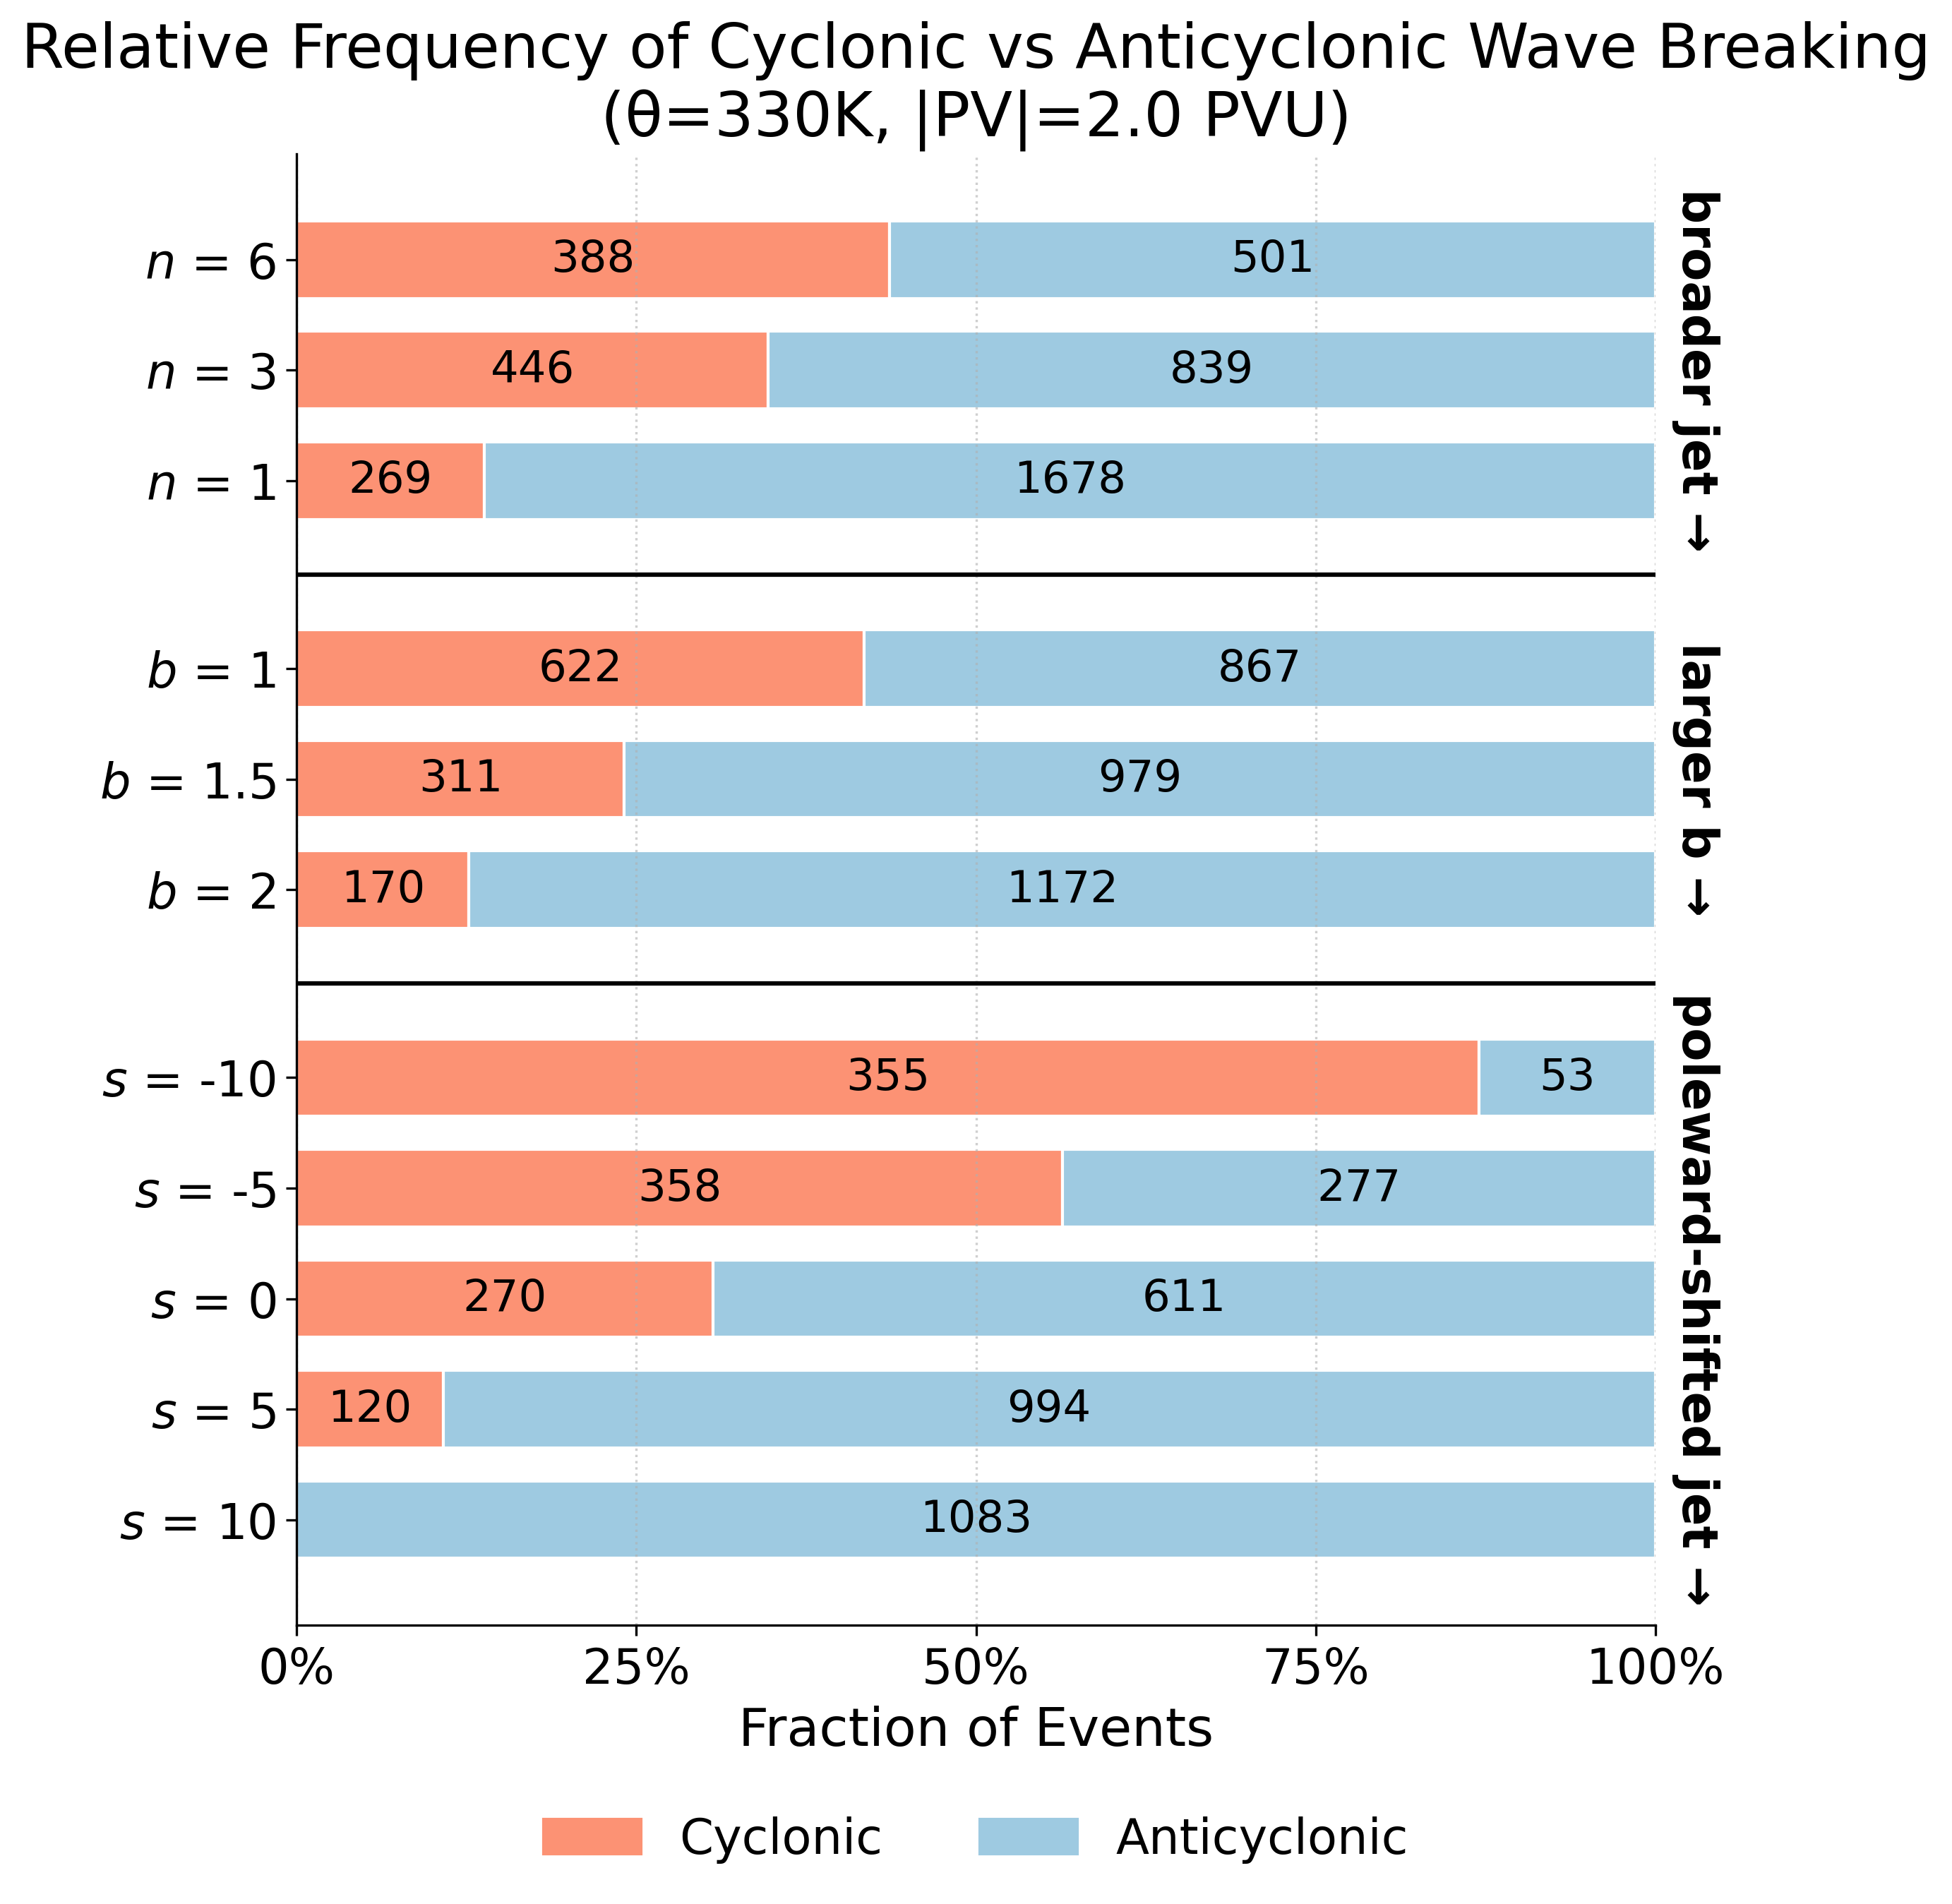

In [11]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure5()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure5_RWB_object_time_statistics.png'])


## Figure 6


In [12]:
def plot_figure6():
    import os
    import xarray as xr
    import numpy as np
    import matplotlib.pyplot as plt
    g = 9.81
    Rd = 287.05
    Cp = 1004.0
    p0 = 100000.0
    path = str(RAW_DIR)
    b_values = [2, 15, 1]
    n_values = [6, 3, 1]
    s_values = [0, 10, -10]
    s_colors = {0: 'blue', 10: 'red', -10: 'green'}
    line_styles = {0: 'solid', 10: 'dashed', -10: 'dotted'}
    center = 45
    radius = 45
    ape_init_results = []
    fig, axes = plt.subplots(3, 3, figsize=(16, 14), sharex=True, sharey=True)
    for i, n in enumerate(n_values):
        for j, b in enumerate(b_values):
            ax = axes[j, i]
            x_max = 144
            for s in s_values:
                if s == 0:
                    fname = f'BCwave_b{b}n{n}'
                else:
                    fname = f'BCwave_b{b}n{n}s{s}'
                fp = os.path.join(path, fname + '.nc')
                try:
                    ds = xr.open_dataset(fp, decode_times=False)
                except FileNotFoundError:
                    print(f'⚠️ not found {fname}.nc，skip')
                    continue
                t0 = ds.time.values[0]
                T0 = ds.t_plev.sel(time=t0)
                theta0 = T0 * (p0 / ds.plev) ** (Rd / Cp)
                theta_bar = theta0.mean(dim=['grid_yt', 'grid_xt'])
                theta_prime = theta0 - theta_bar
                eape_density = 0.5 * (g / theta_bar) * theta_prime ** 2
                lat_rad = np.deg2rad(ds.grid_yt)
                weights = np.cos(lat_rad)
                eape_weighted = eape_density.weighted(weights)
                eape_init = eape_weighted.mean(dim=['grid_yt', 'grid_xt', 'plev']).item()
                ape_init_results.append((b, n, s, eape_init))
                u = ds.u_plev
                v = ds.v_plev
                u_bg = u.mean(dim='grid_xt')
                v_bg = v.mean(dim='grid_xt')
                u_p = u - u_bg
                v_p = v - v_bg
                eke = 0.5 * (u_p ** 2 + v_p ** 2)
                eke_band = eke.sel(grid_yt=slice(center - radius, center + radius))
                lat_rad = np.deg2rad(eke_band.grid_yt)
                wts = np.cos(lat_rad)
                eke_w = eke_band.weighted(wts)
                ts = eke_w.mean(dim=['grid_yt', 'grid_xt', 'plev'])
                ts = ts.where(ts.time >= 144, drop=True)
                if ts.size > 0:
                    x_max = max(x_max, float(ts.time.values[-1]))
                ax.plot(ts.time, ts, color=s_colors[s], linestyle=line_styles[s], label=f's={s}', linewidth=2)
                ds.close()
            ax.set_xlim(144, x_max)
            ax.set_ylim(0, 40)
            ax.set_xticks([150, 200, 250, 300, 350])
            ax.set_yticks([0, 20, 40])
            ax.tick_params(labelsize=20)
            for xline in np.arange(144, x_max + 1, 48):
                ax.axvline(xline, color='lightgray', linewidth=0.5, zorder=0)
            for yline in np.arange(0, 41, 10):
                ax.axhline(yline, color='lightgray', linewidth=0.5, linestyle='--', zorder=0)
            idx = j * len(b_values) + i
            letter = chr(ord('a') + idx)
            bb = 1.5 if b == 15 else b
            ax.text(0.5, 1.1, f'({letter}) b={bb}, n={n}', transform=ax.transAxes, fontsize=20, weight='bold', ha='center', va='top')
    fig.text(0.5, 0.0, 'Time (h)', ha='center', fontsize=24)
    fig.text(0.03, 0.5, 'Averaged EKE (m²/s²)', va='center', rotation='vertical', fontsize=24)
    plt.tight_layout(rect=[0.05, 0.15, 1, 0.95])
    return save_figure(fig, 'Figure6_EKE_evolution.png')
    print('\nInitial EAPE for each case (units: [m²/s²] as per unit-mass density):')
    for b, n, s_val, ape_val in ape_init_results:
        print(f'  b={b:>2}, n={n:>2}, s={s_val:>3} → EAPE_init = {ape_val:.3e}')


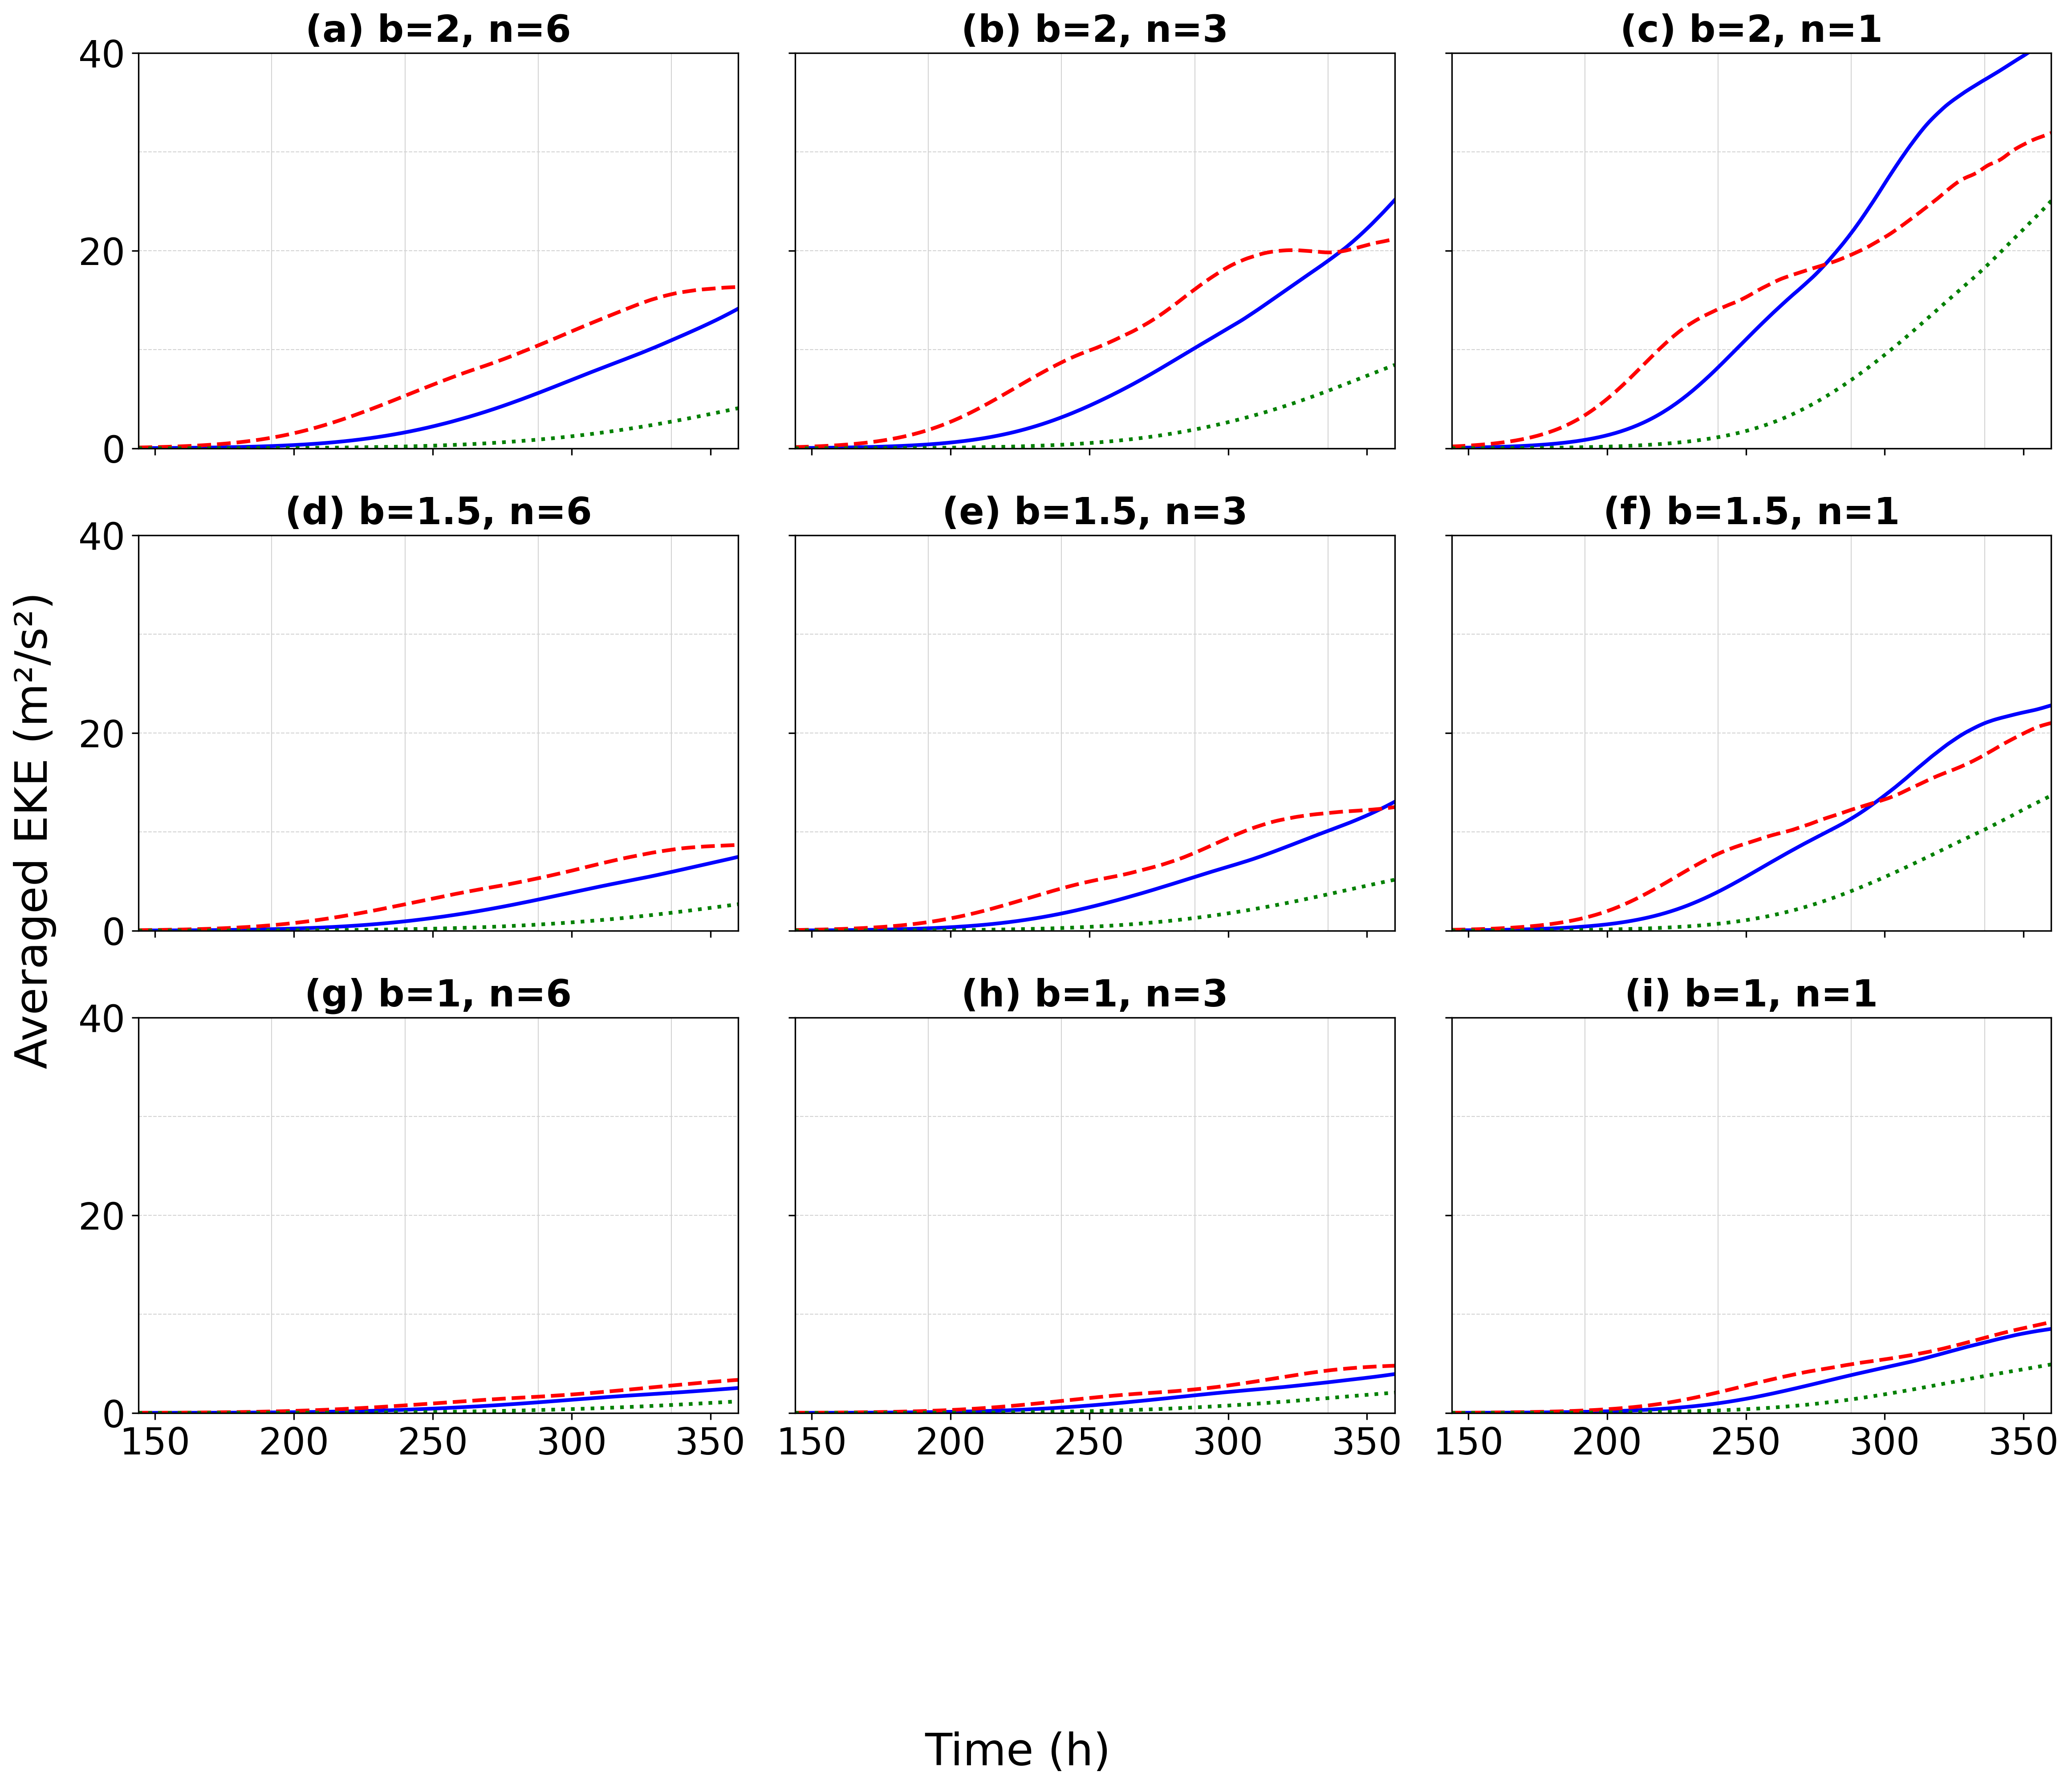

In [13]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure6()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure6_EKE_evolution.png'])
